## Load the dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from keel_ds import load_data

labelmap = {"iris": 4, "wine" : 13, "vehicle": 18, "monk-2": 6, "hayes-roth": 4, "phoneme": 5, "sonar": 60, "ionosphere": 33}
dataname = "wine"
df = load_data(dataname, raw=True)
labelname = labelmap[dataname]
X = np.array(df.drop(labelname, axis=1))
le = preprocessing.LabelEncoder()
y = le.fit_transform(np.array(df[labelname]))
classes = le.classes_
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,12.70,3.55,2.36,21.5,106,1.70,1.20,0.17,0.84,5.00,0.78,1.29,600,3
174,13.32,3.24,2.38,21.5,92,1.93,0.76,0.45,1.25,8.42,0.55,1.62,650,3
175,12.36,3.83,2.38,21.0,88,2.30,0.92,0.50,1.04,7.65,0.56,1.58,520,3
176,12.82,3.37,2.30,19.5,88,1.48,0.66,0.40,0.97,10.26,0.72,1.75,685,3


## Init parameters

In [ ]:
from sklearnapi import WiSARDClassifier

n_bits = 8
n_tics = 64
n_features = len(X[0])
n_classes=len(np.unique(y))
clf = WiSARDClassifier(n_features, n_bits=n_bits, n_tics=n_tics, n_classes=n_classes, random_state=-1)
m,n = clf.getNoRams(), clf.getNoBits()

## Run Genetic Algorithm

In [ ]:
from GA_library import crossover_1d_np, mutate_1d_np, initialize_1d_np, ea_mu_lambda
import time

clf_params={"n_features" : len(X[0]), "n_bits":n_bits, "n_tics":n_tics, "n_classes":n_classes, 
            "bleaching":False, "code":"t", "debug": False}
t1 = time.time()
pop = ea_mu_lambda(
    mu=100,                             # population size (μ parameter)
    lam=100,                            # offspring size (λ parameter)
    tau=50,                             # number of generations
    theta_r=0.5,                        # prob. of crossover
    theta_m=0.2,                        # prob. of mutation       
    m=m,                                # number of encoding bits per feature
    n=n,                                # number of addressing bits
    X=X, y=y,                           # dataset
    clf_params=clf_params,              # WiSARD Classifier parameters
    patience=30,                        # no of offsprings to wait fo early stoping
    start_with_linear=False,            # True if start with a population of linear mappings 
    crossover_fn=crossover_1d_np,       # crossover function 
    mutate_fn=mutate_1d_np,             # mutate function 
    initialize_fn=initialize_1d_np,     # initialization function
    live_plot=True                     # enable plot
)
print("Time: ", time.time()-t1)

Generations:   0%|          | 0/50 [00:00<?, ?it/s]

Offspring:   0%|          | 0/100 [00:00<?, ?it/s]

Offspring:   0%|          | 0/100 [00:00<?, ?it/s]

Offspring:   0%|          | 0/100 [00:00<?, ?it/s]

Offspring:   0%|          | 0/100 [00:00<?, ?it/s]

...

Offspring:   0%|          | 0/100 [00:00<?, ?it/s]

Offspring:   0%|          | 0/100 [00:00<?, ?it/s]

Offspring:   0%|          | 0/100 [00:00<?, ?it/s]

Offspring:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping at generation 30
Time:  13.04121994972229


In [9]:
from GA_library import evaluate
import numpy as np
f = np.array(evaluate(pop[0], X, y, clf_params))
bestmapping = pop[0][f.argmax()]
f[f.argmax()]

0.9887640449438202

ACC:  0.9887640449438202
Time:  0.027685165405273438


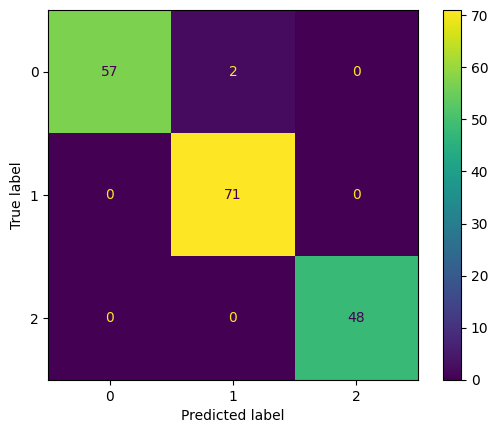

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict, StratifiedKFold
import time

n_features = len(X[0])
n_classes=len(np.unique(y))

t1=time.time()
clf = WiSARDClassifier(n_features, n_bits=n_bits, n_tics=n_tics, n_classes=n_classes, random_state=-1, mapping=bestmapping.ravel(), bleaching=False)
y_pred = cross_val_predict(clf, X, y, cv=5)
cm = confusion_matrix(y, y_pred)
print("ACC: ", accuracy_score(y, y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf._classes)
disp.plot()
print("Time: ", time.time()-t1)
